<a href="https://colab.research.google.com/github/mteuslms/AI-ML-projects/blob/main/Computer_Vision/Tennis_Player_Action_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tennis Player Action Project | Torch | (Image classification)

## Dataset Instructions
This notebook uses the "Tennis Player Actions Dataset for Human Pose Estimation" from Kaggle.
To run this notebook, download the dataset from [Kaggle](https://www.kaggle.com/datasets/orvile/tennis-player-actions-dataset) and upload it to your Colab environment or configure your Kaggle API key.

In [ ]:
pip install kaggle

In [2]:
import os
import zipfile
from google.colab import userdata

# 1. Retrieve Kaggle API Key from Colab Secrets
try:
    KaggleAPIKey = userdata.get('KaggleAPIKey')
    if not KaggleAPIKey:
        raise ValueError("KaggleAPIKey secret not found or is empty.")
except Exception as e:
    print(f"Error retrieving KaggleAPIKey from secrets: {e}")
    KaggleAPIKey = None

kaggle_username = userdata.get('KaggleUsername')

if KaggleAPIKey:
    # 2. Inject credentials directly into environment variables (Bulletproof method)
    os.environ['KAGGLE_USERNAME'] = kaggle_username
    os.environ['KAGGLE_KEY'] = KaggleAPIKey
    print("Kaggle API configured successfully via environment variables!")

    # 3. Download the dataset
    !kaggle datasets download -d orvile/tennis-player-actions-dataset

    # 4. Unzip the downloaded file
    zip_file_name = 'tennis-player-actions-dataset.zip'
    if os.path.exists(zip_file_name):
        with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
            zip_ref.extractall('.')
        print(f"\nExtracted '{zip_file_name}' successfully.")

        # Verify contents
        print("\nContents after extraction:")
        !ls
    else:
        print(f"\nError: '{zip_file_name}' not found. Please ensure the dataset downloaded correctly.")
else:
    print("Kaggle API key configuration failed. Please check the secret.")

Kaggle API configured successfully via environment variables!
Dataset URL: https://www.kaggle.com/datasets/orvile/tennis-player-actions-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 503M/503M [00:29<00:00, 17.9MB/s]


Extracted 'tennis-player-actions-dataset.zip' successfully.

Contents after extraction:
 sample_data
'Tennis Player Actions Dataset for Human Pose Estimation'
 tennis-player-actions-dataset.zip


Finally, I download the dataset, I need to find the specific dataset identifier from Kaggle. So went to the dataset's page on Kaggle, and usually, the download command is provided directly there. It typically looks like `kaggle datasets download -d <owner>/<dataset-slug>`.




In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}") # This should output 'Using device: cuda'

#Training Pipeline (Including Augmentation, using randomHorizontalFlip and Rotation so that a forehand flipped horizontally looks like a left-handed forehand to the model. This forces the transformer to learn the underlying mechanics of the pose rather than memorizing the exact pixel layout of the original 500 images.)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Validation Pipeline (Strictly Deterministic)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_dir = 'Tennis Player Actions Dataset for Human Pose Estimation/images'
dataset_size = len(datasets.ImageFolder(root= data_dir))
train_size = int(0.8 * dataset_size)

#generating random permutation of indices
indices = torch.randperm(dataset_size).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

#creating subsets linking to the distinct transformation pipelines
train_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=train_transforms), train_indices)
val_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=val_transforms), val_indices)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers = 0, pin_memory = False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

Using device: cuda


Visualizing augmented training images:


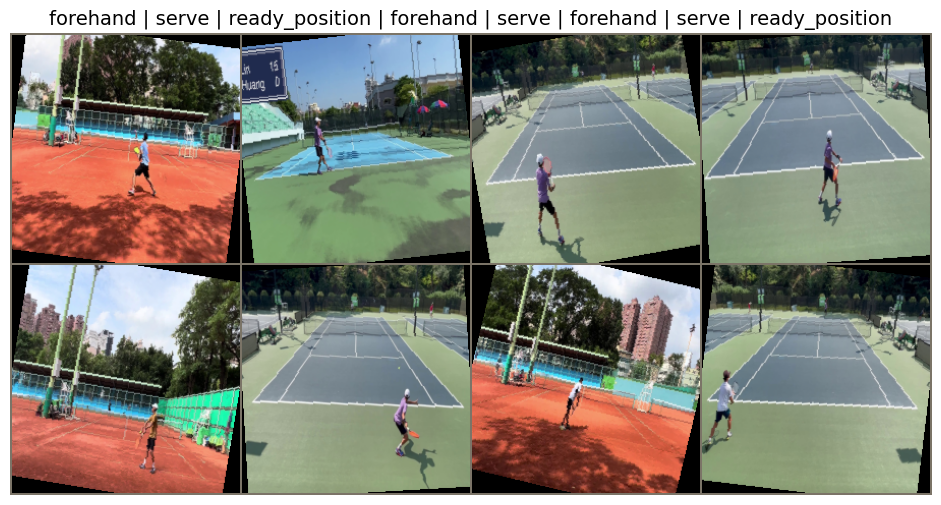

In [ ]:
#Visualizing images
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(img_tensor, title=None):
    # 1. Convert tensor from (Channels, Height, Width) to (Height, Width, Channels) for Matplotlib
    image_np = img_tensor.numpy().transpose((1, 2, 0))

    # 2. Reverse the ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = std * image_np + mean

    # 3. Clip any floating-point errors to strictly stay between 0 and 1
    image_np = np.clip(image_np, 0, 1)

    # 4. Plot the image
    plt.figure(figsize=(15, 6))
    plt.imshow(image_np)
    if title is not None:
        plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

# Extract a single batch from the training loader
images, labels = next(iter(train_loader))

# Grab just the first 8 images from the batch of 64 so it fits nicely on screen
images = images[:8]
labels = labels[:8]

# make_grid stitches the individual image tensors into one large grid tensor
grid_tensor = torchvision.utils.make_grid(images, nrow=4, padding=2)

# Extract the string class names (e.g., 'Forehand', 'Serve') using the ImageFolder attribute
class_names = train_dataset.dataset.classes
batch_titles = " | ".join([class_names[label] for label in labels])

# Visualize
print("Visualizing augmented training images:")
imshow(grid_tensor, title=batch_titles)

# Transformer Block

In [ ]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
  def __init__(self, in_channels=3, patch_size=16, emb_size=768, img_size=224):
    super().__init__()
    self.patch_size = patch_size

    #extracts patches and projects them to the embedding dimension
    self.projection = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size)

    #the learnable classification token
    self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))

    #positional encoding (196 patches + 1 CLS token = 197)
    num_patches = (img_size // patch_size) ** 2
    self.positions = nn.Parameter(torch.randn(1,num_patches + 1, emb_size))

  def forward(self, x):
    b = x.shape[0]
    x = self.projection(x)       # (Batch, 768, 14, 14)
    x = x.flatten(2)             # (Batch, 768, 196)
    x = x.transpose(1, 2)        # (Batch, 196, 768)

    cls_tokens = self.cls_token.expand(b, -1, -1)   # (Batch, 1, 768)
    x = torch.cat((cls_tokens, x), dim = 1)         #(Batch, 197, 768)
    x += self.positions

    return x

class TransformerEncoderBlock(nn.Module):
  def __init__(self, emb_size=768, num_heads=12, forward_expansion=4, dropout=0.1):
    super().__init__()
    self.norm1 = nn.LayerNorm(emb_size)
    self.attention = nn.MultiheadAttention(emb_size, num_heads, dropout = dropout, batch_first = True)
    self.norm2 = nn.LayerNorm(emb_size)

    self.mlp = nn.Sequential(
        nn.Linear(emb_size, forward_expansion * emb_size),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(forward_expansion * emb_size, emb_size),
        nn.Dropout(dropout)
    )

  def forward(self, x):
    #prenorm -> attention -> residual
    normalized_x = self.norm1(x)
    attention_out, _ = self.attention(normalized_x, normalized_x, normalized_x)
    x = x + attention_out

    #pre-norm -> MLP -> Residual
    mlp_out = self.mlp(self.norm2(x))
    x = x + mlp_out

    return x

class VisionTransformer(nn.Module):
  def __init__(self, in_channels=3, patch_size=16, emb_size=768, img_size=224, num_layers=12, num_heads=12, num_classes=4):
    super().__init__()
    self.patch_embed = PatchEmbedding(in_channels, patch_size, emb_size, img_size)

    #stack 12 encoder blocks
    self.encoder = nn.Sequential(
        *[TransformerEncoderBlock(emb_size, num_heads) for _ in range(num_layers)]
        )

    self.norm = nn.LayerNorm(emb_size)
    self.classifier = nn.Linear(emb_size, num_classes)

  def forward(self, x):
    x = self.patch_embed(x)
    x = self.encoder(x)

    #isolate the CLS token (index 0) to feed into the classifier
    cls_token_state = x[:, 0]
    out = self.classifier(self.norm(cls_token_state))
    return out


#instantiate the model and push it to colab GPU
model = VisionTransformer(num_classes = 4).to(device)
print(f"Vision Transformer successfuly initialized on {device}")

Vision Transformer successfuly initialized on cuda


In [ ]:
print("Testing raw dataset access...")
try:
    img, label = train_dataset[0]
    print(f"Success! Image shape: {img.shape}, Label index: {label}")
except Exception as e:
    print(f"Crash during image loading: {e}")

Testing raw dataset access...
Success! Image shape: torch.Size([3, 224, 224]), Label index: 2


# Training Loop

Starting training on cuda for 20 epochs...

Epoch [01/20] | Train Loss: 1.2732 | Train Acc: 37.00% | Val Loss: 1.2537 | Val Acc: 39.00% [Checkpoint Saved]
Epoch [02/20] | Train Loss: 1.2391 | Train Acc: 38.88% | Val Loss: 1.2488 | Val Acc: 38.00%
Epoch [03/20] | Train Loss: 1.2109 | Train Acc: 38.31% | Val Loss: 1.2219 | Val Acc: 40.00% [Checkpoint Saved]
Epoch [04/20] | Train Loss: 1.1598 | Train Acc: 44.88% | Val Loss: 1.1493 | Val Acc: 46.00% [Checkpoint Saved]
Epoch [05/20] | Train Loss: 1.1235 | Train Acc: 48.44% | Val Loss: 1.0456 | Val Acc: 50.25% [Checkpoint Saved]
Epoch [06/20] | Train Loss: 1.0857 | Train Acc: 48.81% | Val Loss: 1.1530 | Val Acc: 47.75%
Epoch [07/20] | Train Loss: 1.0334 | Train Acc: 52.25% | Val Loss: 0.9579 | Val Acc: 57.00% [Checkpoint Saved]
Epoch [08/20] | Train Loss: 0.9829 | Train Acc: 53.81% | Val Loss: 0.9886 | Val Acc: 58.25% [Checkpoint Saved]
Epoch [09/20] | Train Loss: 0.9675 | Train Acc: 56.88% | Val Loss: 1.0160 | Val Acc: 53.75%
Epoch [10/20] 

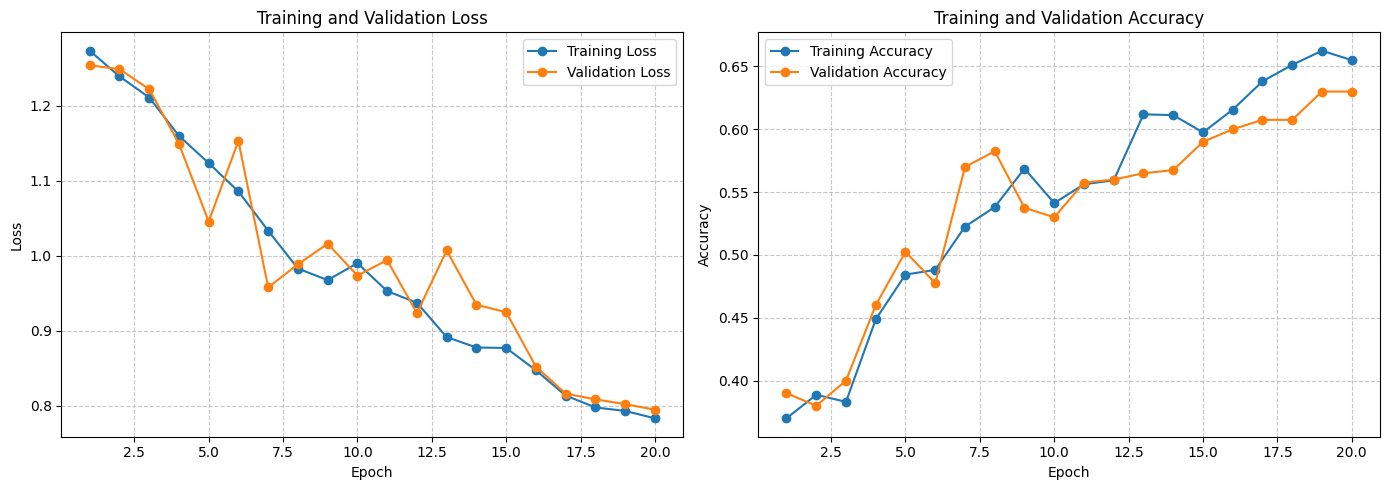

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay = 0.01)

epochs = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = epochs)

best_val_acc = 0.0

# 1. Initialize tracking lists
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

print(f"Starting training on {device} for {epochs} epochs...\n")

for epoch in range(epochs):
    # ==========================
    #       TRAINING PHASE
    # ==========================
    model.train()
    train_loss, train_correct, train_total = 0.0,0,0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    epoch_train_loss = train_loss/train_total
    epoch_train_acc = train_correct/train_total

    #=============================
    #     VALIDATION PHASE
    #=============================
    model.eval()

    # FIXED: Changed var_loss to val_loss
    val_loss, val_correct, val_total = 0.0,0,0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss/val_total
    epoch_val_acc = val_correct/val_total

    scheduler.step()

    # 2. Store metrics for visualization
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_model_vit.pth')
        checkpoint_msg = " [Checkpoint Saved]"
    else:
        checkpoint_msg = ""

    print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc * 100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc * 100:.2f}%"
          f"{checkpoint_msg}")

#========================
#    PLOTTING METRICS
#========================
epochs_range = range(1, epochs+1)

plt.figure(figsize=(14, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()